In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Setting edge 1 for compact support Multiedge graph

#Step Sizes with h corresponding to space and k to time
h = 0.1
k = 0.004
x = np.arange(-200, -10 + h, h)
t = np.arange(0, 25 + k, k)

#Step Function Initial Conditions

initialConditions = []
for element in x:
    initialConditions.append(1)
    
initialConditions_1 = np.array(initialConditions, dtype = 'float64')

In [3]:
#Setting first edge, e2, of multiedge for compact support multiedge graph

#Step Sizes with h corresponding to space and k to time
h = 0.1
k = 0.004
x = np.arange(-10, 10 + h, h)
t = np.arange(0, 25 + k, k)

initialConditions = []
x_0 = 0
A = 0.6
for element in x:
    numerator = -1
    denominator = A * (1 - ((element - x_0)/(10))**2)
    if denominator == 0:
        initialConditions.append(0)
    else:
        #initialConditions.append(numerator/denominator)
        initialConditions.append(np.exp((-1)/(1 - ((element - x_0)/(35))**2)))

initialConditions_2 = np.array(initialConditions, dtype = 'float64')

In [4]:
#Setting second edge, e3, of multiedge for compact support multiedge graph

#Step Sizes with h corresponding to space and k to time
h = 0.1
k = 0.004
x = np.arange(-10, 10 + h, h)
t = np.arange(0, 25 + k, k)

initialConditions = []
x_0 = 0
A = 0.6
for element in x:
    numerator = -1
    denominator = A * (1 - ((element - x_0)/(10))**2)
    if denominator == 0:
        initialConditions.append(0)
    else:
        #initialConditions.append(numerator/denominator)
        initialConditions.append(np.exp((-1)/(1 - ((element - x_0)/(10))**2)))

initialConditions_3 = np.array(initialConditions, dtype = 'float64')

In [5]:
#Setting edge 4 for compact support Multiedge graph

#Step Sizes with h corresponding to space and k to time
h = 0.1
k = 0.001
x = np.arange(10, 200 + h, h)
t = np.arange(0, 25 + k, k)

#Step Function Initial Conditions

initialConditions = []
for element in x:
    initialConditions.append(0)
    
initialConditions_4 = np.array(initialConditions, dtype = 'float64')

In [6]:

#Takes in an initial condition array and forces nuemann boundary conditions on it
def nuemann_conditions(u, i, j):
    N = len(u)
    u[i] = u[j]
    
    return u

#Takes in 3 edge arrays and forces them to have the same vertex conditions
def vertex_conditions(e1, e2, e3, e4):
    N = len(e1)
    vertex_val_1 = (e1[-2] + e2[1] + e3[1])/3
    vertex_val_2 = (e4[1] + e2[-2] + e3[-2])/3

    #Equality at the vertices
    e1[-1] = vertex_val_1
    e2[0] = vertex_val_1
    e3[0] = vertex_val_1
    e4[0] = vertex_val_2
    e2[-1] = vertex_val_2
    e3[-1] = vertex_val_2
    

    return e1, e2, e3, e4
    
    
#Establishing a function to perform FTCS calculation given time and position
def ftcs_comp(dt, dx, u):

    #x = np.linspace(0, space, s_points + 1)
    #t = np.linspace(0, time, t_points)
    
    u_new = np.zeros_like(u, dtype = 'float64')

    N = len(u)
    factor = dt/(dx**2)

    for j in range(1, N-1):
        
        # diffusion part
        diffusion = factor * (u[j+1] - 2*u[j] + u[j-1])

        # reaction part 
        reaction = dt * u[j] * (1.0 - u[j])

        # add them together
        u_new[j] = u[j] + diffusion + reaction

    return u_new

In [7]:
#Establishing the final simulation function
def final_sim(e1, e2, e3, e4, time, t_step, space, s_step):
    t_array = np.linspace(0, time, int(time/t_step))
    t_array_2 = []
    out_4_list = []
    for unit in t_array:
        
        #Establishing Boundary Conditions
        e1 = nuemann_conditions(e1, 0, 2)
        e4 = nuemann_conditions(e4, -1, -3)
        

        #Establishing Vertex Conditions
        e1, e2, e3, e4 = vertex_conditions(e1, e2, e3, e4)

        #Perform FTCS Computation
        e1 = ftcs_comp(t_step, s_step, e1)
        e2 = ftcs_comp(t_step, s_step, e2)
        e3 = ftcs_comp(t_step, s_step, e3)
        e4 = ftcs_comp(t_step, s_step, e4)

        t_array_2.append(unit)
        out_4_list.append(e4)
                      

    return e1, e2, e3, e4, t_array_2, out_4_list

        

    

In [67]:
e1, e2, e3, e4, time, out_4_list = final_sim(initialConditions_1, initialConditions_2, 
                                     initialConditions_3, initialConditions_4, 
                                     90, 0.004, 100, 0.1)
e1[0]

np.float64(0.0)

In [209]:
#Recreating Speed Calculation for this Graph

theta = 0.5
xt_list = []
t_list = []


def ss_calc_right(scan_edge, dx, theta):
    for index in range(len(scan_edge)):
        if scan_edge[index] >= theta and scan_edge[index + 1] < theta:
            xi = (index * dx) + 10
            cross_index = index
            cross_loc = scan_edge[index]
            break
        else:
            cross_index = 0
    if cross_index == 0:
        x_theta_tn = 0
    else:
        numerator = scan_edge[cross_index] - theta
        denominator = scan_edge[cross_index] - scan_edge[cross_index + 1]
        x_theta_tn = xi + (dx * (numerator / denominator))
    
    return x_theta_tn, xi

def ss_calc_left(scan_edge, dx, theta):
    for index in range(1, len(scan_edge)):
        if scan_edge[index - 1] <= theta and scan_edge[index] > theta:
            xi = (index * dx) - 200
            cross_index = index
            cross_loc = scan_edge[index]
    numerator = scan_edge[cross_index] - theta
    denominator = scan_edge[cross_index - 1] - scan_edge[cross_index]
    x_theta_tn = xi + (dx * (numerator / denominator))
    
    return x_theta_tn

def ss_calc_mult(scan_edge, dx, theta):
    for index in range(1,len(scan_edge)):
        if scan_edge[index - 1] >= theta and scan_edge[index] < theta:
            xi = (index * dx) - 10
            cross_index = index
            cross_loc = scan_edge[index]
    numerator = scan_edge[cross_index] - theta
    denominator = scan_edge[cross_index - 1] - scan_edge[cross_index]
    x_theta_tn = xi + (dx * (numerator / denominator))
    
    return x_theta_tn





In [210]:
#Revised Speed Calculation

pair_list = []
for index in range(len(time)):
    x_theta_t, cross_t = ss_calc_right(out_4_list[index], 0.1, theta)
    pair_1 = [time[index], x_theta_t]
    pair_list.append(pair_1)


pair_list[1]

[np.float64(0.004000177785679363), 0]

In [211]:
pair_array = np.array(pair_list)

t_vals = pair_array[:, 0]
x_vals = pair_array[:, 1]

t_cutoff = 0.7 * max(t_vals)

late_mask = t_vals >= t_cutoff

t_late = t_vals[late_mask]
x_late = x_vals[late_mask]

slope, intercept = np.polyfit(t_late, x_late, 1)

traveling_speed = slope
traveling_speed

np.float64(1.9741941628096475)

/var/folders/pg/0k9px6td5pxgysg_gvkp_2t40000gn/T/ipykernel_97822/2260811147.py:3: RuntimeWarning: invalid value encountered in divide
  ratio = x_vals / t_vals


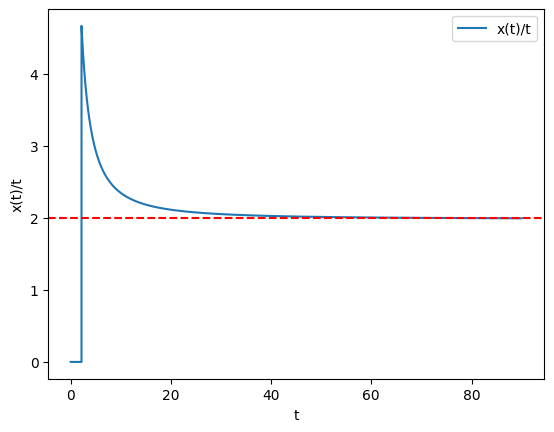

In [212]:
t_cutoff = 0.7 * max(t_vals)

ratio = x_vals / t_vals
mask = t_vals > 0

t_plot = t_vals[mask]
ratio_plot = ratio[mask]

plt.plot(t_plot, ratio_plot, label="x(t)/t")

# regression speed
plt.axhline(y=2, color='red', linestyle='--')

plt.xlabel("t")
plt.ylabel("x(t)/t")
plt.legend()
plt.show()

In [213]:
spreading_speed = ratio[-1]
spreading_speed

np.float64(1.9954976814368)

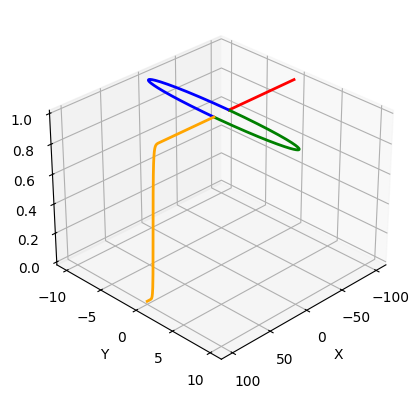

In [214]:
# Edge 1 (incoming)
x1 = np.linspace(-100, -10, len(e1))
y1 = np.zeros_like(x1)

# Edge 4 (outgoing)
x4 = np.linspace(10, 100, len(e4))
y4 = np.zeros_like(x4)

# Radius of cycle
R = 10

theta2 = np.linspace(np.pi, 0, len(e2))
theta3 = np.linspace(np.pi, 0, len(e3))

# Edge 2 (upper arc)
x2 = R * np.cos(theta2)
y2 = R * np.sin(theta2)

# Edge 3 (lower arc)
x3 = R * np.cos(theta3)
y3 = -R * np.sin(theta3)

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(x1[1:-1], y1[1:-1], e1[1:-1], color="red", linewidth=2)
ax.plot(x2[1:-1], y2[1:-1], e2[1:-1], color="green", linewidth=2)
ax.plot(x3[1:-1], y3[1:-1], e3[1:-1], color="blue", linewidth=2)
ax.plot(x4[1:-1], y4[1:-1], e4[1:-1], color="orange", linewidth=2)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('u')

ax.view_init(30, 45)

plt.show()

In [239]:
#Calculating speed in a short window after the vertex at full time

theta = e4[150]

pair_list = []
for index in range(len(time)):
    x_theta_t, cross_t = ss_calc_right(out_4_list[index], 0.1, theta)
    pair_1 = [time[index], x_theta_t]
    pair_list.append(pair_1)


pair_list[1]


[np.float64(0.004000177785679363), 0]

In [240]:
pair_array = np.array(pair_list)

t_vals = pair_array[:, 0]
x_vals = pair_array[:, 1]

t_cutoff = 0.7 * max(t_vals)

late_mask = t_vals >= t_cutoff

t_late = t_vals[late_mask]
x_late = x_vals[late_mask]

slope, intercept = np.polyfit(t_late, x_late, 1)

traveling_speed = slope
traveling_speed

np.float64(1.9636935022570623)

In [241]:
t_cutoff = 0.7 * max(t_vals)

ratio = x_vals / t_vals

spreading_speed = ratio[-1]
spreading_speed

/var/folders/pg/0k9px6td5pxgysg_gvkp_2t40000gn/T/ipykernel_97822/3741458631.py:3: RuntimeWarning: invalid value encountered in divide
  ratio = x_vals / t_vals


np.float64(1.1566666666666667)